In [ ]:
!pip install --upgrade openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.8/999.8 kB 20.4 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.109.1
    Uninstalling openai-1.109.1:
      Successfully uninstalled openai-1.109.1


In [ ]:
import os, getpass
from openai import OpenAI

# Memasukkan API key secara aman (di Colab)
os.environ["OPENAI_API_KEY"] = getpass.getpass("🔑 Enter your OpenAI API key: ")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
print("✅ OpenAI client ready.")


🔑 Enter your OpenAI API key: ··········
✅ OpenAI client ready.


In [ ]:
resp = client.chat.completions.create(
    model="gpt-4o-mini",
    temperature=0.0,
    messages=[
        {"role": "system", "content": "You respond only in JSON."},
        {"role": "user", "content": "Return a JSON object with a field 'hello' set to 'world'."}
    ]
)
print(resp.choices[0].message.content)

```json
{
  "hello": "world"
}
```


In [ ]:
import pathlib
LOG_F = pathlib.Path("kg_augmented")
LOG_F.mkdir(exist_ok=True)
LOG_F = LOG_F / "llm_logs_openai.jsonl"

In [ ]:
import json, re, time, random

def llm_generate_openai(target: str, k: int = 6, retries: int = 3) -> dict:
    """
    Uses GPT-4o-mini to generate structured JSON edges for a target label.
    Retries automatically on errors and logs every prompt/response.
    """
    label_str = ", ".join(LABELS)
    relations = ", ".join(REL_ALLOWED)

    prompt = f"""
You are constructing a commonsense graph for multi-label image classification.
Use ONLY these relations: {relations}.
Entities MUST come from this closed label list: {label_str}.
Propose up to {k} edges where the target = "{target}" connects to other entities
that frequently co-occur in photographs.

Return VALID JSON ONLY in this exact schema:
{{
 "target": "string",
 "edges": [
   {{"h":"string","r":"string","t":"string","confidence":float,"justification":"string"}}
 ],
 "notes": "string"
}}
No explanations or text outside JSON.
"""

    for attempt in range(1, retries + 1):
        try:
            completion = client.chat.completions.create(
                model="gpt-4o-mini",
                temperature=0.0,
                messages=[
                    {"role": "system", "content": "You generate structured JSON only."},
                    {"role": "user", "content": prompt},
                ],
            )
            text = completion.choices[0].message.content.strip()
            with open(LOG_F, "a", encoding="utf-8") as f:
                f.write(json.dumps({"target": target, "raw": text}, ensure_ascii=False) + "\n")

            try:
                data = json.loads(text)
            except json.JSONDecodeError:
                match = re.search(r"\{.*\}", text, re.DOTALL)
                if match:
                    data = json.loads(match.group(0))
                else:
                    raise ValueError("No JSON object in response")

            if "edges" not in data:
                raise ValueError("JSON has no 'edges' field")

            return data

        except Exception as e:
            print(f"[WARN] Retry {attempt}/{retries} for '{target}':", e)
            if attempt == retries:
                return {"target": target, "edges": [], "notes": "retry_exhausted"}
            time.sleep(0.8 * attempt + random.random() * 0.3)


In [ ]:
# Common COCO-style labels (you can shorten or extend)
LABELS = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat",
    "traffic light","fire hydrant","stop sign","bench","bird","cat","dog","horse",
    "sheep","cow","elephant","bear","zebra","giraffe","backpack","umbrella","handbag",
    "tie","suitcase","frisbee","skis","snowboard","sports ball","kite","baseball bat",
    "baseball glove","skateboard","surfboard","tennis racket","bottle","wine glass","cup",
    "fork","knife","spoon","bowl","banana","apple","sandwich","orange","broccoli",
    "carrot","hot dog","pizza","donut","cake","chair","couch","potted plant","bed",
    "dining table","toilet","tv","laptop","mouse","remote","keyboard","cell phone","microwave",
    "oven","toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear",
    "hair drier","toothbrush"
]

interesting_concepts = ('person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
                        'traffic_light', 'fire_hydrant', 'street_sign', 'stop_sign', 'parking_meter', 'bench',
                        'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
                        'hat', 'backpack', 'umbrella', 'shoe', 'eyeglasses', 'handbag', 'tie', 'suitcase',
                        'frisbee', 'skis', 'snowboard', 'sports_ball', 'kite', 'baseball_bat', 'baseball_glove',
                        'skateboard', 'surfboard', 'tennis_racket', 'bottle', 'plate', 'wine_glass', 'cup',
                        'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
                        'carrot', 'hot_dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted_plant', 'bed',
                        'mirror', 'dining_table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse',
                        'remote', 'keyboard', 'cell_phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
                        'blender', 'book', 'clock', 'vase', 'scissors', 'teddy_bear', 'hair_dryer', 'toothbrush',
                        'hair_brush'
                        )
COCO_CLASSES = (
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
    'traffic_light', 'fire_hydrant', 'stop_sign', 'parking_meter', 'bench',
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports_ball', 'kite', 'baseball_bat', 'baseball_glove', 'skateboard', 'surfboard',
    'tennis_racket', 'bottle', 'wine_glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot_dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted_plant', 'bed', 'dining_table', 'toilet',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell_phone', 'microwave', 'oven',
    'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy_bear',
    'hair_drier', 'toothbrush'
)

# Use this as the label list everywhere else
LABELS = list(interesting_concepts)


# Allowed relation types
REL_ALLOWED = [
    "RelatedTo","AtLocation","PartOf","UsedFor","HasA","IsA","LocatedNear","SimilarTo"
]

REL_ALLOWED1 = [
    "RelatedTo",       # General semantic association
    "IsA",             # X is a type/kind of Y
    "PartOf",          # X is part of Y
    "HasA",            # X has Y as a component
    "UsedFor",         # X is used for Y
    "CapableOf",       # X can perform Y
    "AtLocation",      # X is located at Y
    "LocatedNear",     # X is near Y
    "HasProperty",     # X has property Y
    "MadeOf",          # X is made of Y
    "CreatedBy",       # X is created by Y
    "Causes",          # X causes Y
    "Desires",         # X desires Y
    "MotivatedByGoal", # X is motivated by goal Y
    "HasPrerequisite", # X requires Y before happening
    "HasSubevent",     # X includes Y as subevent
    "Entails",         # X entails Y logically
    "SimilarTo",       # X is similar to Y
    "Synonym",         # X is equivalent to Y
    "Antonym",         # X is opposite of Y
    "DistinctFrom",    # X and Y are distinct concepts
    "ReceivesAction",  # X receives action Y
    "CausesDesire",    # X causes desire for Y
    "DerivedFrom",     # X is derived from Y
    "SymbolOf",        # X represents Y
    "DefinedAs"        # X is defined as Y
]



In [ ]:
test_target = "mirror"
raw = llm_generate_openai(test_target, k=6)
print(json.dumps(raw, indent=2)[:800])


{
  "target": "mirror",
  "edges": [
    {
      "h": "person",
      "r": "RelatedTo",
      "t": "mirror",
      "confidence": 0.9,
      "justification": "People often look into mirrors."
    },
    {
      "h": "bathroom",
      "r": "AtLocation",
      "t": "mirror",
      "confidence": 0.85,
      "justification": "Mirrors are commonly found in bathrooms."
    },
    {
      "h": "bedroom",
      "r": "AtLocation",
      "t": "mirror",
      "confidence": 0.8,
      "justification": "Mirrors are frequently located in bedrooms."
    },
    {
      "h": "hair_brush",
      "r": "UsedFor",
      "t": "mirror",
      "confidence": 0.75,
      "justification": "Hair brushes are often used in front of mirrors."
    },
    {
      "h": "makeup",
      "r": "UsedFor",
      "t": "mirror",
  


In [ ]:
from difflib import get_close_matches

# Define the label set (in lowercase)
LABEL_SET = {l.lower() for l in LABELS}

# ✅ Comprehensive alias mapping: spaces ↔ underscores, singular/plural, and common variants
ALIASES = {
    # Common underscore/space variants
    "cellphone": "cell_phone",
    "mobile_phone": "cell_phone",
    "cell phone": "cell_phone",
    "traffic-light": "traffic_light",
    "traffic light": "traffic_light",
    "tv monitor": "tv",
    "television": "tv",
    "firehydrant": "fire_hydrant",
    "fire hydrant": "fire_hydrant",
    "stop-sign": "stop_sign",
    "stop sign": "stop_sign",
    "parking meter": "parking_meter",
    "parking-meter": "parking_meter",
    "sports ball": "sports_ball",
    "baseball bat": "baseball_bat",
    "baseball glove": "baseball_glove",
    "tennis racket": "tennis_racket",
    "potted plant": "potted_plant",
    "dining table": "dining_table",
    "hair drier": "hair_drier",
    "teddy bear": "teddy_bear",
    "hot dog": "hot_dog",
    "cell-phone": "cell_phone",
    "bookcase": "book",
    "sofa": "couch",
    "plant": "potted_plant",
    "keyboard": "keyboard",
    "remote control": "remote",
    "mic": "microwave",
    "fire_extinguisher": "fire_hydrant",  # sometimes confused
    "mouse_device": "mouse",
    "monitor": "tv",
}

def normalize_label(x: str) -> str | None:
    """
    Normalize a label name (from LLM or dataset) into the official COCO class naming.
    - Handles underscores, dashes, plurals, spaces
    - Falls back to fuzzy matching if alias not found
    """
    x0 = x.strip().lower().replace("-", "_").replace(" ", "_")
    if x0 in LABEL_SET:
        return x0
    if x0 in ALIASES:
        target = ALIASES[x0]
        return target if target in LABEL_SET else None
    # Fuzzy match fallback
    cand = get_close_matches(x0, LABEL_SET, n=1, cutoff=0.86)
    return cand[0] if cand else None


REL_MAP = {
    "near":"LocatedNear","nextto":"LocatedNear","next_to":"LocatedNear","beside":"LocatedNear",
    "in":"AtLocation","on":"AtLocation","inside":"AtLocation",
    "part-of":"PartOf","has-a":"HasA","similar":"SimilarTo","similar_to":"SimilarTo",
    "related":"RelatedTo","is-a":"IsA"
}
def normalize_relation(r: str) -> str | None:
    r0 = r.strip()
    if r0 in REL_ALLOWED: return r0
    r1 = r0.replace(" ", "").replace("-", "").lower()
    mapped = REL_MAP.get(r1)
    return mapped if (mapped in REL_ALLOWED) else None

# --- Pydantic schema (keeps us honest) ---
from pydantic import BaseModel, Field, ValidationError, field_validator
from typing import List, Literal, Optional

class Edge(BaseModel):
    h: str
    r: Literal["RelatedTo","AtLocation","PartOf","UsedFor","HasA","IsA","LocatedNear","SimilarTo"]
    t: str
    confidence: float = Field(0.5, ge=0.0, le=1.0)
    justification: Optional[str] = None
    @field_validator('h','t')
    @classmethod
    def closed_world(cls, v):
        v = v.strip().lower()
        assert v in LABEL_SET, f"{v} not in label set"
        return v

class LLMResponse(BaseModel):
    target: str
    edges: List[Edge]
    notes: Optional[str] = None


In [ ]:
samples = ["traffic light", "cellphone", "fire hydrant", "parking meter", "sofa", "mouse_device", "sports ball"]
for s in samples:
    print(f"{s:20s} → {normalize_label(s)}")


traffic light        → traffic_light
cellphone            → cell_phone
fire hydrant         → fire_hydrant
parking meter        → parking_meter
sofa                 → couch
mouse_device         → mouse
sports ball          → sports_ball


In [ ]:
import time, random, json

MAX_LABELS = 1000            # expand later if you want
K_EDGES_PER_TARGET = 8     # request more edges for coverage
SLEEP_BETWEEN_CALLS = 0.4  # gentle rate limiting

def generate_edges_for_all(labels: list, k_each=6, limit=12):
    all_clean = []
    for target in labels[:limit]:
        raw = llm_generate_openai(target, k=k_each)  # uses your OpenAI function
        if "edges" not in raw or not isinstance(raw["edges"], list):
            print(f"[WARN] no 'edges' field for {target}"); continue

        # normalize raw JSON
        norm_edges = []
        for e in raw["edges"]:
            h = normalize_label(e.get("h","")); t = normalize_label(e.get("t",""))
            r = normalize_relation(e.get("r",""))
            if h and t and r and h != t:
                norm_edges.append({
                    "h": h, "t": t, "r": r,
                    "confidence": float(max(0,min(1, e.get("confidence",0.5)))),
                    "justification": e.get("justification","")
                })

        if not norm_edges:
            print(f"[INFO] all edges dropped after normalization for target={target}")
            continue

        # validate
        try:
            resp = LLMResponse(target=target, edges=[Edge(**e) for e in norm_edges])
        except ValidationError as e:
            print("[VALIDATION] failed for", target, e); continue

        all_clean.extend([ee.model_dump() for ee in resp.edges])
        time.sleep(SLEEP_BETWEEN_CALLS)

    print("Collected normalized edges:", len(all_clean))
    # also save the cleaned edges
    import pathlib
    out = pathlib.Path("kg_augmented"); out.mkdir(exist_ok=True)
    with open(out/"aug_edges_clean.jsonl","w",encoding="utf-8") as f:
        for e in all_clean: f.write(json.dumps(e, ensure_ascii=False)+"\n")
    return all_clean

edges_clean = generate_edges_for_all(LABELS, k_each=K_EDGES_PER_TARGET, limit=MAX_LABELS)
len(edges_clean)


[INFO] all edges dropped after normalization for target=bird
Collected normalized edges: 363


363

In [ ]:
import math, itertools, numpy as np
import networkx as nx
from collections import defaultdict

# tiny synthetic co-occurrence prior — replace with real stats later if you have them
def sigmoid(x): return 1/(1+math.exp(-x))
def synthesize_cooccurrence(labels, n_images=1500, p_on=0.06):
    mh = []
    for _ in range(n_images):
        vec = (np.random.rand(len(labels)) < p_on).astype(int)
        if vec[labels.index("person")] == 1:
            for nm in ["bench","car","dog","cell phone"]:
                if nm in labels and random.random() < 0.4:
                    vec[labels.index(nm)] = 1
        mh.append(vec.tolist())
    return mh
def compute_npmi(label_multi_hot, labels):
    X = np.array(label_multi_hot, dtype=np.int32)
    n = X.shape[0] + 1e-12
    p = X.sum(axis=0) / n
    Pij = (X.T @ X) / n
    out = {}
    for i,j in itertools.combinations(range(len(labels)), 2):
        pij = Pij[i,j]
        if pij <= 0 or p[i] <= 0 or p[j] <= 0: npmi = -1.0
        else:
            pmi = math.log(pij / (p[i]*p[j]) + 1e-12)
            npmi = pmi / (-math.log(pij + 1e-12))
        out[(labels[i], labels[j])] = npmi
        out[(labels[j], labels[i])] = npmi
    for i,l in enumerate(labels): out[(l,l)] = 0.0
    return out

multi_hot = synthesize_cooccurrence(LABELS, n_images=1500, p_on=0.06)
NPMI = compute_npmi(multi_hot, LABELS)

def get_clip_scores(pairs):
    # lightweight heuristic prior; ok to keep 0.0 if you don't want this
    out = {}
    for (h,t) in pairs:
        base = 0.05
        if "person" in (h,t): base += 0.25
        if set([h,t]) == set(["bench","tree"]): base += 0.2
        out[(h,t)] = min(1.0, base)
    return out

def score_edges_with_relation(edges, beta=(0.5,0.1,0.4), alpha=4.0, tau=0.45):
    """
    Returns dict keyed by (h,t,r) -> weight
    beta weights: data prior, clip prior, llm confidence
    """
    pairs = [(e['h'], e['t']) for e in edges]
    clip_scores = get_clip_scores(pairs)
    best = {}
    for e in edges:
        h,t,r = e['h'], e['t'], e['r']
        conf = float(e.get('confidence',0.5))
        npmi = NPMI.get((h,t), -1.0)
        s_data = sigmoid(alpha * npmi) if npmi > -1 else 0.0
        s_clip = clip_scores.get((h,t), 0.0)
        w = beta[0]*s_data + beta[1]*s_clip + beta[2]*conf
        if w >= tau:
            key = (h,t,r)
            if w > best.get(key, 0.0): best[key] = w
    return best

edge_scores_rel = score_edges_with_relation(edges_clean, beta=(0.5,0.1,0.4), alpha=4.0, tau=0.45)
len(edge_scores_rel)


303

Edges: 222


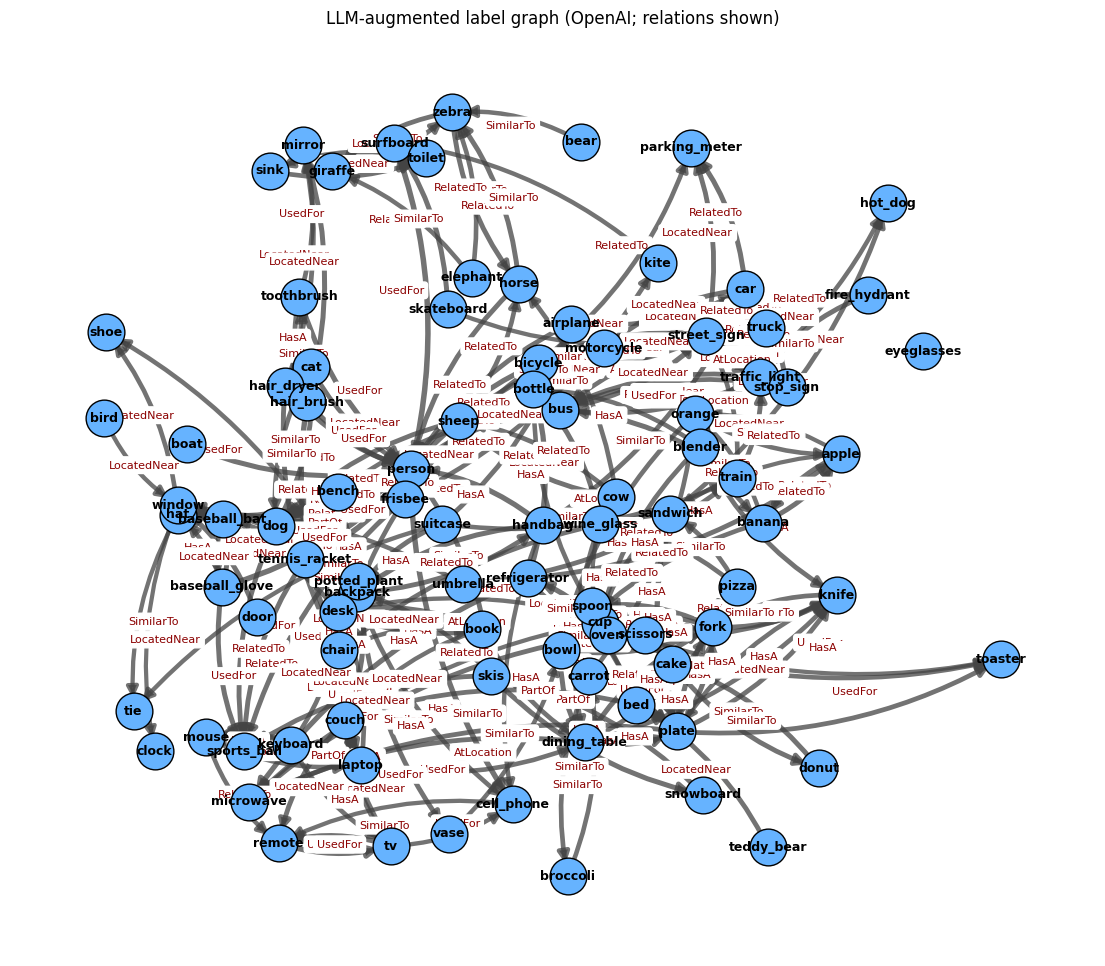

In [ ]:
def build_digraph_with_relation(labels, scores_rel, topk_out=4):
    G = nx.DiGraph(); G.add_nodes_from(labels)
    out = defaultdict(list)
    for (h,t,r), w in scores_rel.items(): out[h].append((t,r,w))
    for h, lst in out.items():
        for (t,r,w) in sorted(lst, key=lambda x: x[2], reverse=True)[:topk_out]:
            G.add_edge(h, t, weight=w, relation=r)
    return G

G_rel = build_digraph_with_relation(LABELS, edge_scores_rel, topk_out=4)
print("Edges:", G_rel.number_of_edges())

import matplotlib.pyplot as plt
pos = nx.spring_layout(G_rel, seed=7, k=0.35)
plt.figure(figsize=(14,12))
nx.draw_networkx_nodes(G_rel, pos, node_size=700, node_color="#66b3ff", edgecolors="black")
nx.draw_networkx_labels(G_rel, pos, font_size=9, font_weight="bold")

edges = list(G_rel.edges(data=True))
widths = [1.2 + 4*d["weight"] for _,_,d in edges]
nx.draw_networkx_edges(G_rel, pos, [(u,v) for u,v,_ in edges],
    arrows=True, arrowstyle='-|>', arrowsize=16, width=widths,
    edge_color="#444", alpha=0.75, connectionstyle='arc3,rad=0.15')

edge_labels = {(u,v): d['relation'] for u,v,d in edges}
nx.draw_networkx_edge_labels(G_rel, pos, edge_labels=edge_labels,
    font_color="darkred", font_size=8, rotate=False, label_pos=0.55)

plt.title("LLM-augmented label graph (OpenAI; relations shown)")
plt.axis("off"); plt.show()


In [ ]:
import numpy as np, pathlib

def collapse_to_adjacency(labels, scores_rel, topk=5, undirected=True):
    idx = {l.lower(): i for i,l in enumerate(labels)}
    W = np.zeros((len(labels), len(labels)), dtype=np.float32)
    for (h,t,r), w in scores_rel.items():
        i,j = idx[h], idx[t]
        W[i,j] = max(W[i,j], w)
        if undirected: W[j,i] = max(W[j,i], w)
    # sparsify + row-normalize
    for i in range(W.shape[0]):
        row = W[i]
        if row.sum() == 0: continue
        keep = row.argsort()[-topk:]
        mask = np.zeros_like(row, dtype=bool); mask[keep] = True
        row[~mask] = 0.0
        s = row.sum();
        if s > 0: row /= s
        W[i] = row
    return W

A_aug = collapse_to_adjacency(LABELS, edge_scores_rel, topk=5, undirected=True)

out = pathlib.Path("kg_augmented"); out.mkdir(exist_ok=True)
np.savez_compressed(out/"A_aug.npz", A=A_aug, labels=np.array(LABELS))
print("Saved:", out/"A_aug.npz")


Saved: kg_augmented/A_aug.npz


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

save_dir = "/content/drive/MyDrive/KGGCN_Augmentation"
os.makedirs(save_dir, exist_ok=True)

print("Saving to:", save_dir)


Saving to: /content/drive/MyDrive/KGGCN_Augmentation


In [ ]:
import shutil

# Copy (preserve originals)
shutil.copy("kg_augmented/A_aug.npz", f"{save_dir}/A_aug.npz")
shutil.copy("kg_augmented/aug_edges_clean.jsonl", f"{save_dir}/aug_edges_clean.jsonl")
shutil.copy("kg_augmented/llm_logs_openai.jsonl", f"{save_dir}/llm_logs_openai.jsonl")

print("✅ Files saved to Google Drive!")


✅ Files saved to Google Drive!


In [ ]:
import glob
print(glob.glob(f"{save_dir}/*"))

['/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info.json', '/content/drive/MyDrive/KGGCN_Augmentation/A_aug.npz', '/content/drive/MyDrive/KGGCN_Augmentation/llm_logs_openai.jsonl', '/content/drive/MyDrive/KGGCN_Augmentation/aug_edges_clean.jsonl', '/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_80_reduced.json', '/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_hybrid.json', '/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai.json', '/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_normalized_with_voc.json']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

# adjust the path to match your folder
file_path = "/content/drive/MyDrive/KGGCN_Augmentation/A_aug.npz"

data = np.load(file_path, allow_pickle=True)
A_aug = data["A"]
labels = list(data["labels"])

print("✅ Loaded from Google Drive:", A_aug.shape, "labels:", len(labels))


✅ Loaded from Google Drive: (91, 91) labels: 91


In [ ]:
print(A_aug[:3, :3])      # small sample of matrix
print(labels[:10])        # first few labels


[[0.         0.         0.        ]
 [0.22353697 0.         0.        ]
 [0.         0.         0.        ]]
[np.str_('person'), np.str_('bicycle'), np.str_('car'), np.str_('motorcycle'), np.str_('airplane'), np.str_('bus'), np.str_('train'), np.str_('truck'), np.str_('boat'), np.str_('traffic_light')]


In [ ]:
import numpy as np
import json
import pathlib

# --- 1️⃣ Load your matrix from the npz ---


# adjust the path to match your folder
file_path = "/content/drive/MyDrive/KGGCN_Augmentation/A_aug.npz"

data = np.load(file_path, allow_pickle=True)
A_aug = data["A"]
labels = list(data["labels"])

print("✅ Loaded A_aug.npz:", A_aug.shape, "labels:", len(labels))

# --- 2️⃣ (Optional) Symmetrize like CM_kg_55_info.json ---
S = (A_aug + A_aug.T) / 2.0

# --- 3️⃣ Wrap it in the correct JSON structure ---
kg_json = {
    "KG_COCO_info": {
        "S": S.tolist()
    }
}

# --- 4️⃣ Save to file (in same folder or to Drive) ---
out_path = pathlib.Path("CM_kg_55_info_openai.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(kg_json, f, ensure_ascii=False, indent=2)

print("✅ Saved as:", out_path)


✅ Loaded A_aug.npz: (91, 91) labels: 91
✅ Saved as: CM_kg_55_info_openai.json


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("CM_kg_55_info_openai.json", "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai.json")

print("📁 File saved in Google Drive/KGGCN_Augmentation/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 File saved in Google Drive/KGGCN_Augmentation/


Matrix shape: (91, 91)
First 10 labels: [np.str_('person'), np.str_('bicycle'), np.str_('car'), np.str_('motorcycle'), np.str_('airplane'), np.str_('bus'), np.str_('train'), np.str_('truck'), np.str_('boat'), np.str_('traffic_light')]


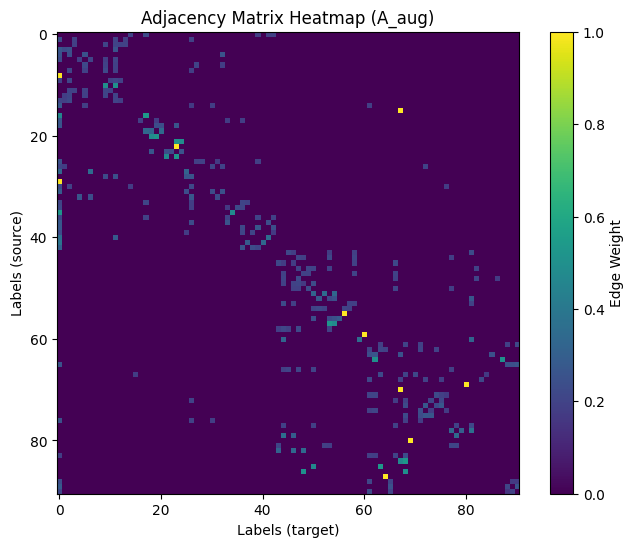

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure A_aug and labels are already loaded
print("Matrix shape:", A_aug.shape)
print("First 10 labels:", labels[:10])

plt.figure(figsize=(8,6))
plt.imshow(A_aug, cmap="viridis", interpolation="nearest")
plt.colorbar(label="Edge Weight")
plt.title("Adjacency Matrix Heatmap (A_aug)")
plt.xlabel("Labels (target)")
plt.ylabel("Labels (source)")
plt.show()


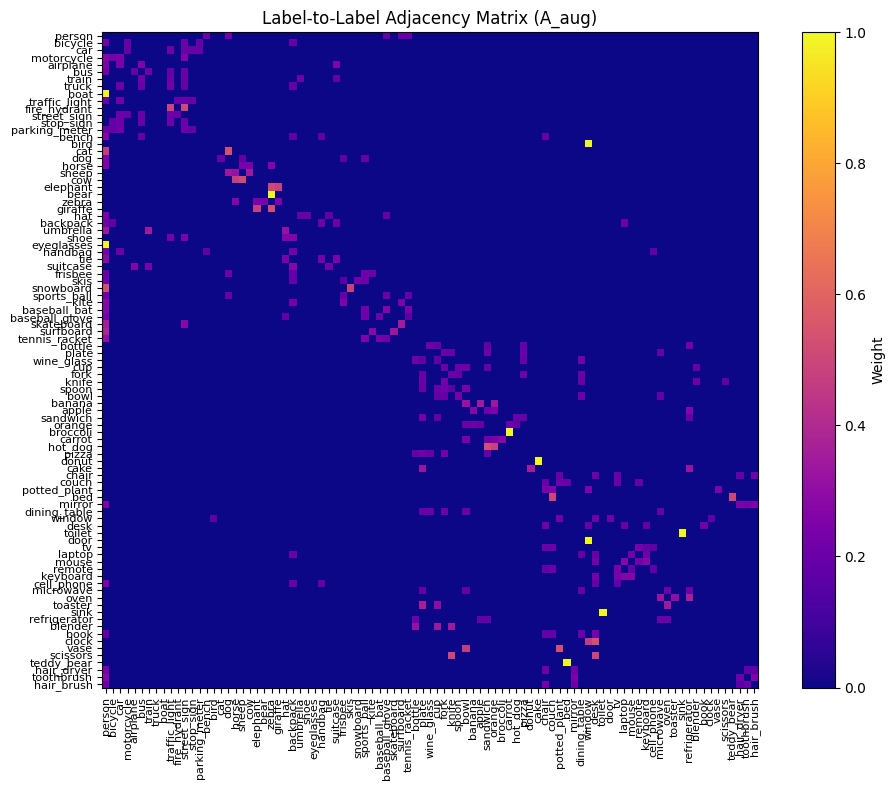

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(A_aug, cmap="plasma", interpolation="nearest")
plt.colorbar(label="Weight")

n = len(labels)
plt.xticks(range(n), labels, rotation=90, fontsize=8)
plt.yticks(range(n), labels, fontsize=8)
plt.title("Label-to-Label Adjacency Matrix (A_aug)")
plt.tight_layout()
plt.show()


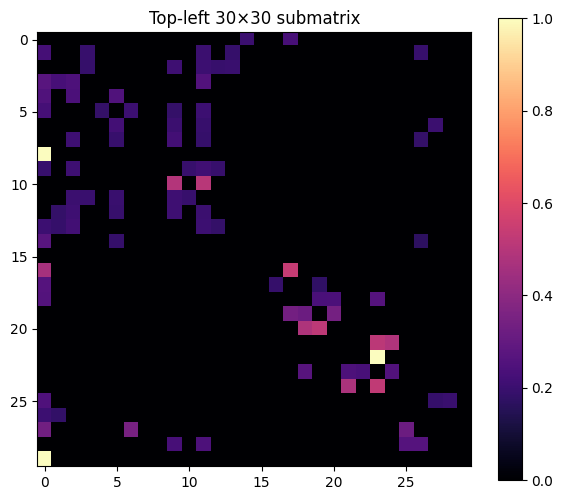

In [ ]:
plt.figure(figsize=(7,6))
plt.imshow(A_aug[:30, :30], cmap="magma")
plt.title("Top-left 30×30 submatrix")
plt.colorbar()
plt.show()


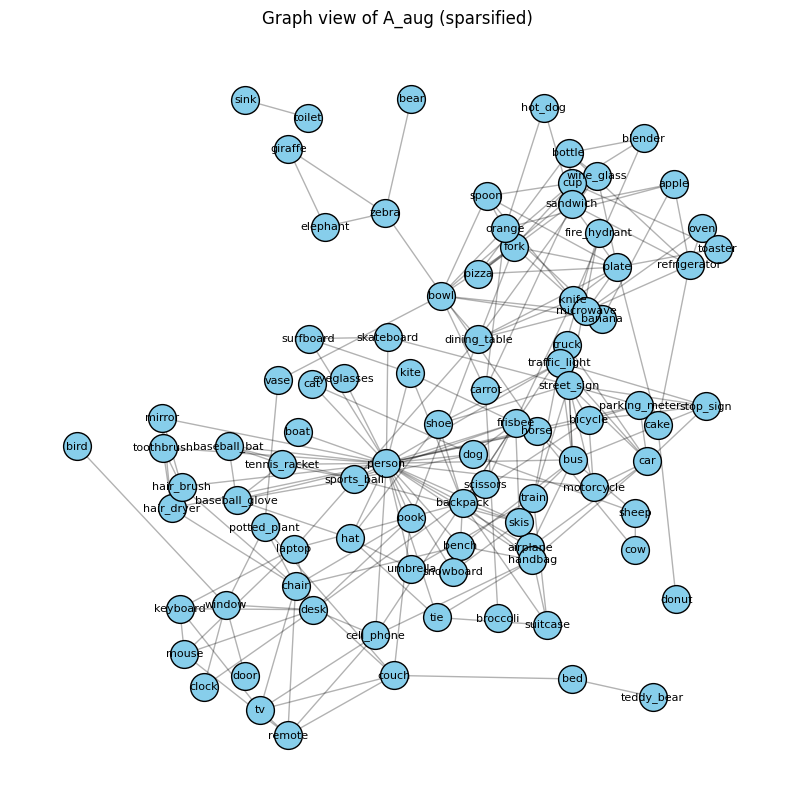

In [ ]:
import networkx as nx

G = nx.from_numpy_array(A_aug)
G = nx.relabel_nodes(G, {i: labels[i] for i in range(len(labels))})

plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, seed=7, k=0.3)
nx.draw_networkx_nodes(G, pos, node_size=400, node_color="skyblue", edgecolors="black")
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Graph view of A_aug (sparsified)")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt

# --- Load OpenAI adjacency ---
path_openai = "/content/drive/MyDrive/KGGCN_Augmentation/A_aug.npz"
data_openai = np.load(path_openai, allow_pickle=True)
A_openai = data_openai["A"]
labels_openai = list(data_openai["labels"])
print("✅ Loaded OpenAI matrix:", A_openai.shape, "labels:", len(labels_openai))

# --- Load original CM_kg_55_info.json ---
path_orig = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info.json"
with open(path_orig, "r", encoding="utf-8") as f:
    data_orig = json.load(f)
A_orig = np.array(data_orig["KG_COCO_info"]["S"], dtype=float)
print("✅ Loaded original matrix:", A_orig.shape)


✅ Loaded OpenAI matrix: (91, 91) labels: 91
✅ Loaded original matrix: (91, 91)


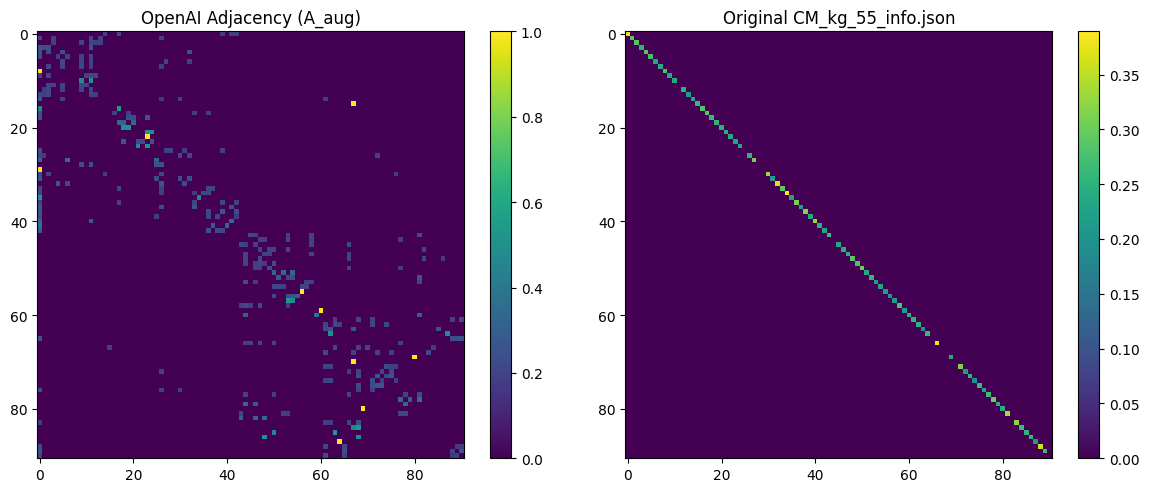

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(A_openai, cmap="viridis")
plt.title("OpenAI Adjacency (A_aug)")
plt.colorbar(fraction=0.046)

plt.subplot(1,2,2)
plt.imshow(A_orig, cmap="viridis")
plt.title("Original CM_kg_55_info.json")
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()


✅ Loaded CM matrix: (91, 91)


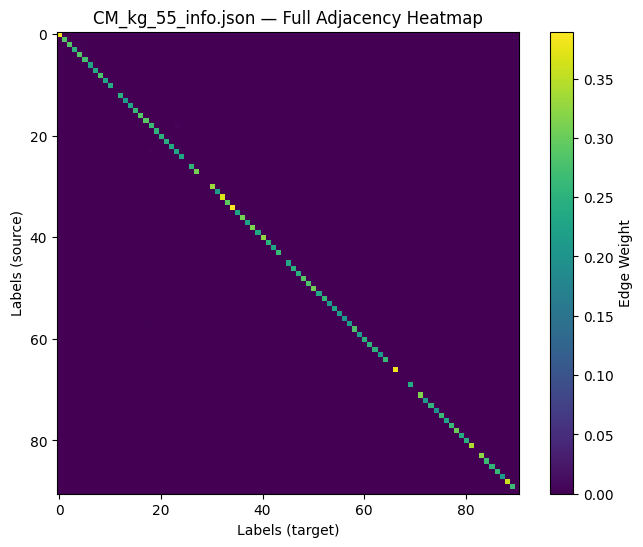

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Path to your file
CM_JSON = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info.json"

# Load the JSON
with open(CM_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract the adjacency matrix
A_cm = np.array(data["KG_COCO_info"]["S"], dtype=float)
print("✅ Loaded CM matrix:", A_cm.shape)

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(A_cm, cmap="viridis")
plt.colorbar(label="Edge Weight")
plt.title("CM_kg_55_info.json — Full Adjacency Heatmap")
plt.xlabel("Labels (target)")
plt.ylabel("Labels (source)")
plt.show()


Graph nodes: 57, edges (>0.0002): 70


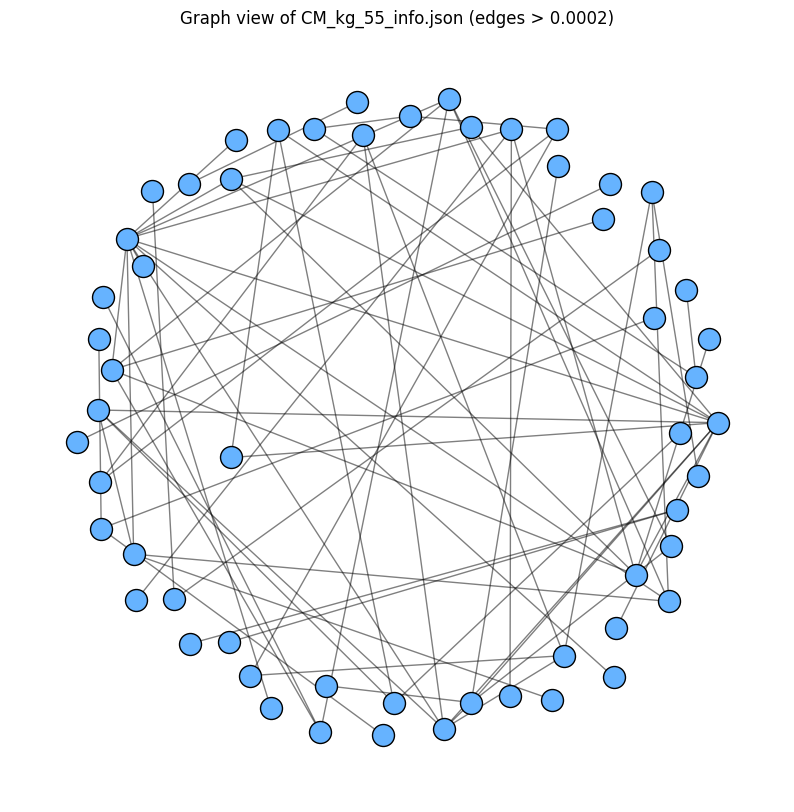

In [ ]:
import networkx as nx


# Build graph (only edges above a threshold for readability)
threshold = 0.0002  # adjust for clarity
G = nx.Graph()
G = nx.relabel_nodes(G, {i: labels[i] for i in range(len(labels))})
n = A_cm.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if A_cm[i, j] > threshold:
            G.add_edge(i, j, weight=A_cm[i, j])

print(f"Graph nodes: {len(G.nodes())}, edges (>{threshold}): {len(G.edges())}")

# Plot graph
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=7, k=0.3)
nx.draw_networkx_nodes(G, pos, node_size=250, node_color="#66b3ff", edgecolors="black")
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.title(f"Graph view of CM_kg_55_info.json (edges > {threshold})")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np, json

with open("/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info.json", "r") as f:
    data = json.load(f)
A = np.array(data["KG_COCO_info"]["S"], dtype=float)

print("Matrix shape:", A.shape)
print("Min value:", A.min())
print("Max value:", A.max())
print("Mean value:", A.mean())


Matrix shape: (91, 91)
Min value: 0.0
Max value: 0.38943903696144244
Mean value: 0.0025720288550577543


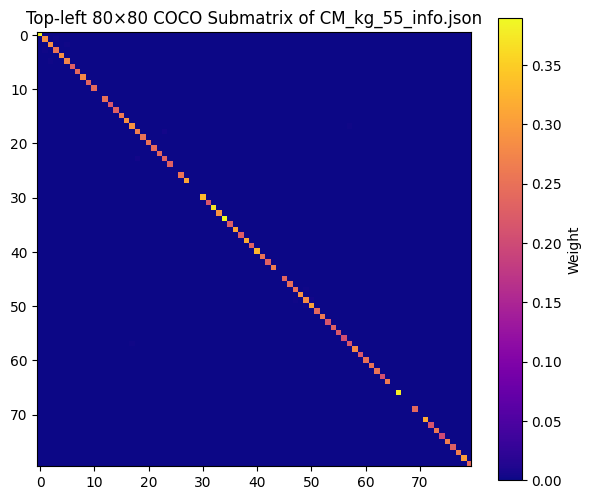

In [ ]:
plt.figure(figsize=(7,6))
plt.imshow(A_cm[:80, :80], cmap="plasma")
plt.colorbar(label="Weight")
plt.title("Top-left 80×80 COCO Submatrix of CM_kg_55_info.json")
plt.show()


In [ ]:
# =====================================================
# 🧠 Create KG_VOC_info (20x20) inside your OpenAI KG file
# =====================================================
from google.colab import drive
import json, numpy as np, os

# --- 1. Mount Google Drive
drive.mount('/content/drive')

# --- 2. Define file paths
INPUT_JSON  = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai.json"      # your source OpenAI KG
OUTPUT_JSON = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_with_voc.json"

# --- 3. Load OpenAI KG
with open(INPUT_JSON, "r") as f:
    data = json.load(f)

A_coco = np.array(data["KG_COCO_info"]["S"], dtype=float)

# --- 4. Define class lists
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
                        'traffic_light', 'fire_hydrant', 'street_sign', 'stop_sign', 'parking_meter', 'bench',
                        'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
                        'hat', 'backpack', 'umbrella', 'shoe', 'eyeglasses', 'handbag', 'tie', 'suitcase',
                        'frisbee', 'skis', 'snowboard', 'sports_ball', 'kite', 'baseball_bat', 'baseball_glove',
                        'skateboard', 'surfboard', 'tennis_racket', 'bottle', 'plate', 'wine_glass', 'cup',
                        'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
                        'carrot', 'hot_dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted_plant', 'bed',
                        'mirror', 'dining_table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse',
                        'remote', 'keyboard', 'cell_phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
                        'blender', 'book', 'clock', 'vase', 'scissors', 'teddy_bear', 'hair_dryer', 'toothbrush',
                        'hair_brush'
]



VOC_CLASSES = [
    'airplane','bicycle','bird','boat','bottle',
    'bus','car','cat','chair','cow',
    'dining_table','dog','horse','motorcycle','person',
    'potted_plant','sheep','sofa','train','tv'
]

# --- 5. COCO → VOC mapping (1-based in papers → convert to 0-based)
coco_to_voc_1based = [5, 2, 16, 9, 44, 6, 3, 17, 62, 21, 67, 18, 19, 4, 1, 64, 20, 63, 7, 72]
coco_to_voc = [i-1 for i in coco_to_voc_1based]

# --- 6. Extract 20x20 VOC adjacency
A_voc = A_coco[np.ix_(coco_to_voc, coco_to_voc)]

# --- 7. Add KG_VOC_info + metadata
data["KG_VOC_info"] = {"S": A_voc.tolist()}
data["meta"] = {
    "COCO_classes": COCO_CLASSES,
    "VOC_classes": VOC_CLASSES,
    "coco_to_voc_indices_1based": coco_to_voc_1based,
    "note": "VOC subgraph (20x20) extracted from COCO OpenAI KG using coco_to_voc mapping."
}

# --- 8. Save to Drive
with open(OUTPUT_JSON, "w") as f:
    json.dump(data, f, indent=2)

print(f"✅ File with KG_VOC_info saved to:\n{OUTPUT_JSON}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ File with KG_VOC_info saved to:
/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_with_voc.json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (91, 91)
Range before normalization: 0.0 → 1.0
Range after normalization: 0.0 → 0.9999999999989999
VOC subgraph shape: (20, 20) Range: 0.0 → 1.0
✅ Saved normalized + VOC version:
/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_normalized_with_voc.json


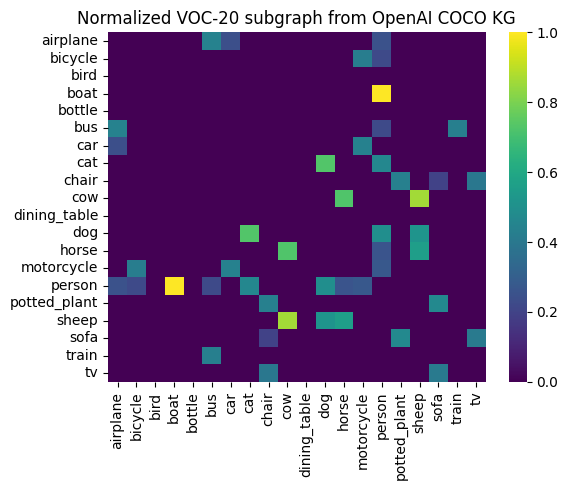

In [ ]:
# ============================================================
# 🧠 Normalize OpenAI KG and add VOC-20 subgraph (COCO→VOC map)
# ============================================================
from google.colab import drive
import json, numpy as np, os
from sklearn.preprocessing import minmax_scale
import seaborn as sns, matplotlib.pyplot as plt

# --- 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# --- 2️⃣ Define paths
INPUT_PATH  = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai.json"
OUTPUT_PATH = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_normalized_with_voc.json"

# --- 3️⃣ Load the JSON
with open(INPUT_PATH, 'r') as f:
    data = json.load(f)
A = np.array(data["KG_COCO_info"]["S"], dtype=float)

print("Original shape:", A.shape)
print("Range before normalization:", A.min(), "→", A.max())

# --- 4️⃣ Normalize full COCO adjacency to [0,1]
A_min, A_max = A.min(), A.max()
A_norm = (A - A_min) / (A_max - A_min + 1e-12)
A_norm = np.nan_to_num(A_norm)
print("Range after normalization:", A_norm.min(), "→", A_norm.max())

# --- 5️⃣ Define COCO 80 & VOC 20 classes + mapping
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
                        'traffic_light', 'fire_hydrant', 'street_sign', 'stop_sign', 'parking_meter', 'bench',
                        'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
                        'hat', 'backpack', 'umbrella', 'shoe', 'eyeglasses', 'handbag', 'tie', 'suitcase',
                        'frisbee', 'skis', 'snowboard', 'sports_ball', 'kite', 'baseball_bat', 'baseball_glove',
                        'skateboard', 'surfboard', 'tennis_racket', 'bottle', 'plate', 'wine_glass', 'cup',
                        'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
                        'carrot', 'hot_dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted_plant', 'bed',
                        'mirror', 'dining_table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse',
                        'remote', 'keyboard', 'cell_phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
                        'blender', 'book', 'clock', 'vase', 'scissors', 'teddy_bear', 'hair_dryer', 'toothbrush',
                        'hair_brush'
]

VOC_CLASSES = [
    'airplane','bicycle','bird','boat','bottle',
    'bus','car','cat','chair','cow',
    'dining_table','dog','horse','motorcycle','person',
    'potted_plant','sheep','sofa','train','tv'
]

# 1-based mapping (paper) → 0-based for Python
coco_to_voc_1based = [5, 2, 16, 9, 44, 6, 3, 17, 62, 21, 67, 18, 19, 4, 1, 64, 20, 63, 7, 72]
coco_to_voc = [i-1 for i in coco_to_voc_1based]

# --- 6️⃣ Extract VOC-20 submatrix and renormalize it
A_voc = A_norm[np.ix_(coco_to_voc, coco_to_voc)]
A_voc_norm = minmax_scale(A_voc.flatten()).reshape(20,20)

print("VOC subgraph shape:", A_voc_norm.shape,
      "Range:", A_voc_norm.min(), "→", A_voc_norm.max())

# --- 7️⃣ Write back normalized COCO + VOC info
data["KG_COCO_info"]["S"] = A_norm.tolist()
data["KG_VOC_info"] = {"S": A_voc_norm.tolist()}
data["meta"] = {
    "note": "COCO adjacency normalized to [0,1]; KG_VOC_info (20x20) extracted using COCO→VOC mapping",
    "COCO_classes": COCO_CLASSES,
    "VOC_classes": VOC_CLASSES,
    "coco_to_voc_indices_1based": coco_to_voc_1based
}

with open(OUTPUT_PATH, "w") as f:
    json.dump(data, f, indent=2)

print(f"✅ Saved normalized + VOC version:\n{OUTPUT_PATH}")

# --- 8️⃣ (Optional) Visualize VOC subgraph
plt.figure(figsize=(6,5))
sns.heatmap(A_voc_norm, cmap="viridis",
            xticklabels=VOC_CLASSES, yticklabels=VOC_CLASSES)
plt.title("Normalized VOC-20 subgraph from OpenAI COCO KG")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


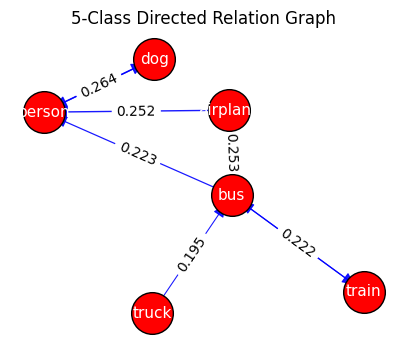

In [ ]:
# --- Draw a 5-class directed relation graph from A_aug.npz ---
from google.colab import drive
drive.mount('/content/drive')

import numpy as np, networkx as nx, matplotlib.pyplot as plt

NPZ_PATH = "/content/drive/MyDrive/KGGCN_Augmentation/A_aug.npz"  # <- change if needed
AUTO_PICK = False   # True = auto-choose 5 most connected (off-diagonal); False = use MANUAL_CLASSES
#MANUAL_CLASSES = ['cat','dog','sheep','cow','horse','person']  # <- edit as you like
MANUAL_CLASSES = ['person', 'dog', 'bus', 'train', 'truck', 'airplane']
TOP_M_EDGES = 20     # keep only the strongest M directed edges among the 5 nodes
ARROW_SCALE = 4.0   # scales edge width; increase if lines look thin

# 1) load
data = np.load(NPZ_PATH, allow_pickle=True)
A = data["A"].astype(float)
labels = list(data["labels"])
n = A.shape[0]

# 2) remove self-loops for selection & drawing
A_no_diag = A.copy()
np.fill_diagonal(A_no_diag, 0.0)

# 3) pick 5 classes
if AUTO_PICK:
    # choose by off-diagonal strength
    strength = A_no_diag.sum(axis=1)
    idx5 = np.argsort(-strength)[:5]
    chosen = [labels[i] for i in idx5]
else:
    chosen = [c for c in MANUAL_CLASSES if c in labels]
    assert len(chosen) == 6, f"Need 5 valid names in MANUAL_CLASSES; got {chosen}"

idx_map = {lab: i for i, lab in enumerate(labels)}
sel_idx = [idx_map[c] for c in chosen]
A5 = A[ np.ix_(sel_idx, sel_idx) ]  # 5x5 directed weights
np.fill_diagonal(A5, 0.0)

# 4) keep only top-M strongest directed edges to avoid clutter
pairs = []
for i, u in enumerate(chosen):
    for j, v in enumerate(chosen):
        if i == j: continue
        w = float(A5[i, j])
        if w > 0: pairs.append((u, v, w))
pairs.sort(key=lambda x: x[2], reverse=True)
pairs = pairs[:TOP_M_EDGES]

# 5) build DiGraph and draw
G = nx.DiGraph()
G.add_nodes_from(chosen)
for u, v, w in pairs:
    G.add_edge(u, v, weight=w)

plt.figure(figsize=(5,4))
pos = nx.spring_layout(G, seed=7, k=0.9)

nx.draw_networkx_nodes(G, pos, node_color="red", node_size=900, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_color="white", font_size=11)

widths = [ARROW_SCALE * d['weight'] for _,_,d in G.edges(data=True)]
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(G.edges()),
    width=widths, alpha=0.9,
    edge_color="blue",
    arrows=True, arrowsize=18, arrowstyle="-|>"  # nice arrowheads
)

edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

plt.title("5-Class Directed Relation Graph")
plt.axis("off")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


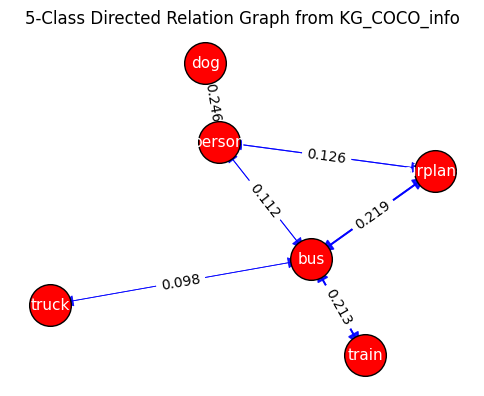

In [ ]:
# --- Draw a 5-class directed relation graph from your JSON ---
from google.colab import drive
drive.mount('/content/drive')

import json, numpy as np, networkx as nx, matplotlib.pyplot as plt

JSON_PATH   = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_normalized_with_voc.json"  # <- update if needed
SECTION     = "KG_COCO_info"   # or "KG_VOC_info" if you want the VOC 20×20 matrix
AUTO_PICK   = False            # True = auto-choose 5 most connected (off-diagonal); False = use MANUAL_CLASSES below
#MANUAL_CLASSES = ['cat','dog','sheep','cow','horse','person']   # pick any 5 present in the labels
MANUAL_CLASSES = ['person', 'dog', 'bus', 'train', 'truck', 'airplane']#
TOP_M_EDGES = 20                # keep only the strongest M directed edges among the 5 nodes (to avoid clutter)
ARROW_SCALE = 6.0              # scales edge width; increase if lines look thin

# Fallback COCO labels (used only if the JSON doesn't include labels)
COCO_CLASSES = [
 'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
 'traffic_light','fire_hydrant','street_sign','stop_sign','parking_meter','bench',
 'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
 'hat','backpack','umbrella','shoe','eyeglasses','handbag','tie','suitcase',
 'frisbee','skis','snowboard','sports_ball','kite','baseball_bat','baseball_glove',
 'skateboard','surfboard','tennis_racket','bottle','plate','wine_glass','cup',
 'fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli',
 'carrot','hot_dog','pizza','donut','cake','chair','couch','potted_plant','bed',
 'mirror','dining_table','window','desk','toilet','door','tv','laptop','mouse',
 'remote','keyboard','cell_phone','microwave','oven','toaster','sink','refrigerator',
 'blender','book','clock','vase','scissors','teddy_bear','hair_dryer','toothbrush','hair_brush'
]

# 1) Load matrix + labels from JSON
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

block = data[SECTION]
S = np.array(block["S"], dtype=float)
labels = block.get("labels")
if not labels or len(labels) != S.shape[0]:
    # fall back if labels missing in JSON
    labels = COCO_CLASSES[: S.shape[0]]

# 2) Remove self-loops for selection & drawing
A = S.copy()
np.fill_diagonal(A, 0.0)

# 3) Pick 5 classes
if AUTO_PICK:
    strength = A.sum(axis=1)                         # off-diagonal strength
    idx5 = np.argsort(-strength)[:5]
    chosen = [labels[i] for i in idx5]
else:
    chosen = [c for c in MANUAL_CLASSES if c in labels]
    assert len(chosen) == 6, f"Need 5 valid names; got {chosen}"

idx = {lab: i for i, lab in enumerate(labels)}
sel = [idx[c] for c in chosen]

A5 = S[np.ix_(sel, sel)].astype(float)               # keep original directional weights
np.fill_diagonal(A5, 0.0)

# 4) Keep top-M strongest directed edges among the 5 nodes
triples = []
for i, u in enumerate(chosen):
    for j, v in enumerate(chosen):
        if i == j: continue
        w = float(A5[i, j])
        if w > 0:
            triples.append((u, v, w))
triples.sort(key=lambda x: x[2], reverse=True)
triples = triples[:TOP_M_EDGES]

# 5) Build DiGraph and draw
G = nx.DiGraph()
G.add_nodes_from(chosen)
for u, v, w in triples:
    G.add_edge(u, v, weight=w)

plt.figure(figsize=(6,4.6))
pos = nx.spring_layout(G, seed=7, k=0.9)

nx.draw_networkx_nodes(G, pos, node_color="red", node_size=900, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_color="white", font_size=11)

widths = [ARROW_SCALE * d['weight'] for _,_,d in G.edges(data=True)]
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(G.edges()),
    width=widths, alpha=0.9,
    edge_color="blue",
    arrows=True, arrowsize=18, arrowstyle="-|>"
)

edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

plt.title(f"5-Class Directed Relation Graph from {SECTION}")
plt.axis("off")
plt.show()


In [ ]:
import json, numpy as np

npz_path  = "/content/drive/MyDrive/KGGCN_Augmentation/A_aug.npz"
json_path = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_normalized_with_voc.json"
five = ['cat','dog','sheep','cow','horse']  # <- your example

# load npz
D = np.load(npz_path, allow_pickle=True)
A = D["A"].astype(float)
labels_npz = list(D["labels"])

# load json
with open(json_path, "r", encoding="utf-8") as f:
    J = json.load(f)
S = np.array(J["KG_COCO_info"]["S"], dtype=float)
labels_json = J["KG_COCO_info"].get("labels", labels_npz)  # fallback if missing

# helper: 5x5 block in given label order
def block(M, labels, names):
    idx = {lab:i for i,lab in enumerate(labels)}
    sel = [idx[n] for n in names]
    return M[np.ix_(sel, sel)]

A5 = block(A, labels_npz, five)
S5 = block(S, labels_json, five)

print("Label order identical?  ", labels_npz == labels_json)
print("A symmetry (||A-Aᵀ||₁): ", np.abs(A - A.T).sum())
print("S symmetry (||S-Sᵀ||₁): ", np.abs(S - S.T).sum())
print("A range: ", A.min(), A.max(), " S range: ", S.min(), S.max())

print("\nA[5x5] (npz):\n", np.round(A5, 3))
print("\nS[5x5] (json):\n", np.round(S5, 3))
print("\nΔ = S - A (5x5):\n", np.round(S5 - A5, 3))


Label order identical?   True
A symmetry (||A-Aᵀ||₁):  70.59593710303307
S symmetry (||S-Sᵀ||₁):  0.0
A range:  0.0 1.0  S range:  0.0 0.9999999999989999

A[5x5] (npz):
 [[0.    0.539 0.    0.    0.   ]
 [0.189 0.    0.179 0.    0.   ]
 [0.    0.338 0.    0.344 0.319]
 [0.    0.    0.517 0.    0.483]
 [0.    0.    0.238 0.24  0.   ]]

S[5x5] (json):
 [[0.    0.364 0.    0.    0.   ]
 [0.364 0.    0.258 0.    0.   ]
 [0.    0.258 0.    0.43  0.279]
 [0.    0.    0.43  0.    0.361]
 [0.    0.    0.279 0.361 0.   ]]

Δ = S - A (5x5):
 [[ 0.    -0.175  0.     0.     0.   ]
 [ 0.175  0.     0.079  0.     0.   ]
 [ 0.    -0.079  0.     0.087 -0.04 ]
 [ 0.     0.    -0.087  0.    -0.122]
 [ 0.     0.     0.04   0.122  0.   ]]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


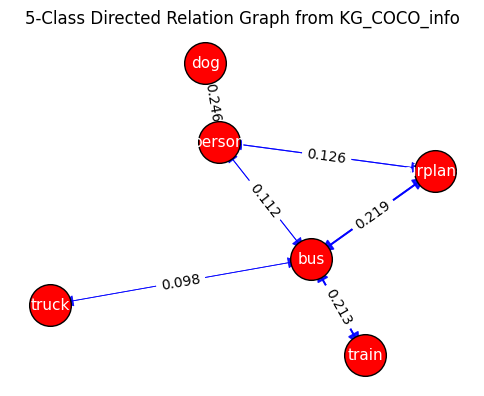

In [ ]:
# --- Draw a 5-class directed relation graph from your JSON ---
from google.colab import drive
drive.mount('/content/drive')

import json, numpy as np, networkx as nx, matplotlib.pyplot as plt

JSON_PATH   = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_leftout.json"  # <- update if needed
SECTION     = "KG_COCO_info"   # or "KG_VOC_info" if you want the VOC 20×20 matrix
AUTO_PICK   = False            # True = auto-choose 5 most connected (off-diagonal); False = use MANUAL_CLASSES below
#MANUAL_CLASSES = ['cat','dog','sheep','cow','horse','person']   # pick any 5 present in the labels

#MANUAL_CLASSES = ['person', 'hat', 'eyeglasses', 'mirror', 'hair_brush', 'bicycle']
#MANUAL_CLASSES = ['person', 'car', 'bus', 'train', 'truck', 'bicycle']
MANUAL_CLASSES = ['person', 'dog', 'bus', 'train', 'truck', 'airplane']
TOP_M_EDGES = 50                # keep only the strongest M directed edges among the 5 nodes (to avoid clutter)
ARROW_SCALE = 6.0              # scales edge width; increase if lines look thin

# Fallback COCO labels (used only if the JSON doesn't include labels)
COCO_CLASSES = [
 'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
 'traffic_light','fire_hydrant','street_sign','stop_sign','parking_meter','bench',
 'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
 'hat','backpack','umbrella','shoe','eyeglasses','handbag','tie','suitcase',
 'frisbee','skis','snowboard','sports_ball','kite','baseball_bat','baseball_glove',
 'skateboard','surfboard','tennis_racket','bottle','plate','wine_glass','cup',
 'fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli',
 'carrot','hot_dog','pizza','donut','cake','chair','couch','potted_plant','bed',
 'mirror','dining_table','window','desk','toilet','door','tv','laptop','mouse',
 'remote','keyboard','cell_phone','microwave','oven','toaster','sink','refrigerator',
 'blender','book','clock','vase','scissors','teddy_bear','hair_dryer','toothbrush','hair_brush'
]

# 1) Load matrix + labels from JSON
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

block = data[SECTION]
S = np.array(block["S"], dtype=float)
labels = block.get("labels")
if not labels or len(labels) != S.shape[0]:
    # fall back if labels missing in JSON
    labels = COCO_CLASSES[: S.shape[0]]

# 2) Remove self-loops for selection & drawing
A = S.copy()
np.fill_diagonal(A, 0.0)

# 3) Pick 5 classes
if AUTO_PICK:
    strength = A.sum(axis=1)                         # off-diagonal strength
    idx5 = np.argsort(-strength)[:5]
    chosen = [labels[i] for i in idx5]
else:
    chosen = [c for c in MANUAL_CLASSES if c in labels]
    assert len(chosen) == 6, f"Need 5 valid names; got {chosen}"

idx = {lab: i for i, lab in enumerate(labels)}
sel = [idx[c] for c in chosen]

A5 = S[np.ix_(sel, sel)].astype(float)               # keep original directional weights
np.fill_diagonal(A5, 0.0)

# 4) Keep top-M strongest directed edges among the 5 nodes
triples = []
for i, u in enumerate(chosen):
    for j, v in enumerate(chosen):
        if i == j: continue
        w = float(A5[i, j])
        if w > 0:
            triples.append((u, v, w))
triples.sort(key=lambda x: x[2], reverse=True)
triples = triples[:TOP_M_EDGES]

# 5) Build DiGraph and draw
G = nx.DiGraph()
G.add_nodes_from(chosen)
for u, v, w in triples:
    G.add_edge(u, v, weight=w)

plt.figure(figsize=(6,4.6))
pos = nx.spring_layout(G, seed=7, k=0.9)

nx.draw_networkx_nodes(G, pos, node_color="red", node_size=900, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_color="white", font_size=11)

widths = [ARROW_SCALE * d['weight'] for _,_,d in G.edges(data=True)]
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(G.edges()),
    width=widths, alpha=0.9,
    edge_color="blue",
    arrows=True, arrowsize=18, arrowstyle="-|>"
)

edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

plt.title(f"5-Class Directed Relation Graph from {SECTION}")
plt.axis("off")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


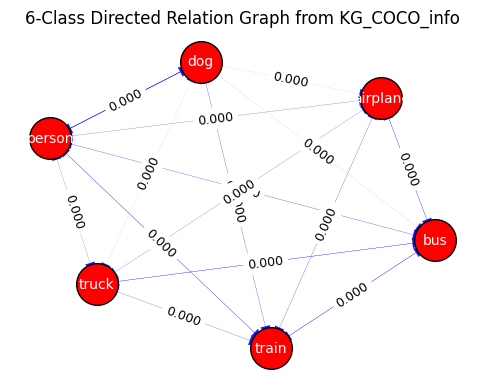

In [ ]:
# --- Draw a directed relation graph from JSON (COCO/VOC) with ANY number of classes ---
from google.colab import drive
drive.mount('/content/drive')

import json, numpy as np, networkx as nx, matplotlib.pyplot as plt

JSON_PATH = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info.json"
SECTION   = "KG_COCO_info"          # or "KG_VOC_info"
AUTO_PICK = False                   # True: auto top-N by off-diagonal strength; False: use MANUAL_CLASSES
#MANUAL_CLASSES = ['cat','dog','cow','horse','sheep','person']   # use ANY length here
# MANUAL_CLASSES = ['person', 'hat', 'eyeglasses', 'mirror', 'hair_brush', 'bicycle']
#MANUAL_CLASSES = ['person', 'car', 'bus', 'train', 'truck', 'bicycle']
MANUAL_CLASSES = ['person', 'dog', 'bus', 'train', 'truck', 'airplane']
N_CLASSES = 12                      # used only if AUTO_PICK=True
TOP_M_EDGES = 200                   # global cap on edges shown
PER_NODE_K = None                   # set to an int (e.g., 3) to keep top-k outgoing edges per node
ARROW_SCALE = 800                   # scale edge widths
SHOW_MIN_EDGE = 0.0                 # keep edges >= this weight

# --- 1) Load JSON ---
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)
block = data[SECTION]
S = np.array(block["S"], dtype=float)
labels = block.get("labels")
if not labels or len(labels) != S.shape[0]:
    # COCO fallback if labels missing
    COCO_CLASSES = [
        'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
        'traffic_light','fire_hydrant','street_sign','stop_sign','parking_meter','bench',
        'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
        'hat','backpack','umbrella','shoe','eyeglasses','handbag','tie','suitcase',
        'frisbee','skis','snowboard','sports_ball','kite','baseball_bat','baseball_glove',
        'skateboard','surfboard','tennis_racket','bottle','plate','wine_glass','cup',
        'fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli',
        'carrot','hot_dog','pizza','donut','cake','chair','couch','potted_plant','bed',
        'mirror','dining_table','window','desk','toilet','door','tv','laptop','mouse',
        'remote','keyboard','cell_phone','microwave','oven','toaster','sink','refrigerator',
        'blender','book','clock','vase','scissors','teddy_bear','hair_dryer','toothbrush','hair_brush'
    ][:S.shape[0]]
    labels = COCO_CLASSES

# --- 2) Remove self-loops (for selection/drawing) ---
A = S.copy()
np.fill_diagonal(A, 0.0)

# --- 3) Choose nodes ---
if AUTO_PICK:
    strength = A.sum(axis=1)            # off-diagonal strength
    idx = np.argsort(-strength)[:N_CLASSES]
    chosen = [labels[i] for i in idx]
else:
    # Use ALL names provided (and present in labels)
    chosen = [c for c in MANUAL_CLASSES if c in labels]
    if len(chosen) < 2:
        raise ValueError("Need at least 2 valid class names in MANUAL_CLASSES")
    N_CLASSES = len(chosen)             # auto-match to manual count

# --- 4) Submatrix for chosen classes ---
idx_map = {lab: i for i, lab in enumerate(labels)}
sel = [idx_map[c] for c in chosen]
A_sub = S[np.ix_(sel, sel)].astype(float)   # keep original weights (S is symmetric)
np.fill_diagonal(A_sub, 0.0)

# --- 5) Build edge list ---
edges = []
if PER_NODE_K is not None:
    # keep top-k outgoing edges per node
    k = int(PER_NODE_K)
    for i, u in enumerate(chosen):
        row = A_sub[i]
        # indices of top-k (excluding self, already 0)
        nbr_idx = np.argsort(-row)[:k]
        for j in nbr_idx:
            if i == j: continue
            w = float(A_sub[i, j])
            if w >= SHOW_MIN_EDGE:
                edges.append((u, chosen[j], w))
    # de-duplicate keeping the max weight per (u,v)
    tmp = {}
    for u, v, w in edges:
        tmp[(u, v)] = max(w, tmp.get((u, v), 0.0))
    edges = [(u, v, w) for (u, v), w in tmp.items()]
else:
    # global top-M across all pairs
    for i, u in enumerate(chosen):
        for j, v in enumerate(chosen):
            if i == j: continue
            w = float(A_sub[i, j])
            if w >= SHOW_MIN_EDGE:
                edges.append((u, v, w))
    edges.sort(key=lambda x: x[2], reverse=True)
    edges = edges[:min(TOP_M_EDGES, N_CLASSES*(N_CLASSES-1))]

# --- 6) Draw ---
G = nx.DiGraph()
G.add_nodes_from(chosen)
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# Scale figure size with number of nodes
side = max(6, int(0.55 * N_CLASSES))
plt.figure(figsize=(side, side*0.75))
pos = nx.spring_layout(G, seed=7, k=1.0/(1+np.log1p(N_CLASSES)))

nx.draw_networkx_nodes(G, pos, node_color="red", node_size=900, edgecolors="black")
nx.draw_networkx_labels(G, pos, font_color="white", font_size=10)

widths = [ARROW_SCALE * d['weight'] for _, _, d in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, edgelist=list(G.edges()), width=widths, alpha=0.9,
                       edge_color="blue", arrows=True, arrowsize=18, arrowstyle="-|>")

edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title(f"{N_CLASSES}-Class Directed Relation Graph from {SECTION}")
plt.axis("off")
plt.show()


In [5]:
import json
import numpy as np

# === CONFIG ===
JSON_PATH = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_fused_soft_union_weighted_a0.7.json"
OUTPUT_PATH = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_fused_soft_union_weighted_a0.7_leftout.json"
SECTION = "KG_COCO_info"
# indices of classes to zero (1-based COCO IDs)
leftouts = [11, 25, 28, 29, 44, 65, 67, 68, 70, 82, 90]

# convert to 0-based indexing
leftouts = [i - 1 for i in leftouts]

# === LOAD JSON ===
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

S = np.array(data[SECTION]["S"], dtype=float)
labels = data[SECTION].get("labels", [])

print("Original shape:", S.shape)


# === ZERO OUT rows & cols ===
for i in leftouts:
    if i < S.shape[0]:
        S[i, :] = 0
        S[:, i] = 0

# === Save modified JSON ===
data[SECTION]["S"] = S.tolist()

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print(f"✅ Saved modified COCO matrix to: {OUTPUT_PATH}")



Original shape: (91, 91)
✅ Saved modified COCO matrix to: /content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_fused_soft_union_weighted_a0.7_leftout.json


|  Index | Class Name       | Category Group       |
| :----: | :--------------- | :------------------- |
| **11** | **fire_hydrant** | outdoor              |
| **25** | **hat**          | accessory            |
| **28** | **shoe**         | accessory            |
| **29** | **eyeglasses**   | accessory            |
| **44** | **plate**        | kitchen              |
| **65** | **mirror**       | indoor               |
| **67** | **window**       | indoor               |
| **68** | **desk**         | indoor               |
| **70** | **tv**           | electronic           |
| **82** | **refrigerator** | appliance            |
| **90** | **hair_brush**   | accessory / personal |


['fire_hydrant', 'hat', 'shoe', 'eyeglasses',
 'plate', 'mirror', 'window', 'desk',
 'tv', 'refrigerator', 'hair_brush']


In [21]:
import numpy as np
S_new = np.array(data[SECTION]["S"])
print("Zeroed indices sum check:")
for i in leftouts:
    print(i, S_new[i].sum(), S_new[:, i].sum())


Zeroed indices sum check:
10 0.0 0.0
24 0.0 0.0
27 0.0 0.0
28 0.0 0.0
43 0.0 0.0
64 0.0 0.0
66 0.0 0.0
67 0.0 0.0
69 0.0 0.0
81 0.0 0.0
89 0.0 0.0


In [21]:
import json
import numpy as np

# === CONFIG ===
JSON_PATH = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_fused_union.json"
OUTPUT_PATH = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_fused_soft_union_weighted_a0.7_leftout.json"
SECTION = "KG_COCO_info"
# indices of classes to zero (1-based COCO IDs)
leftouts1 = [11, 25, 28, 29, 44, 65, 67, 68, 70, 82, 90]
leftouts = [11, 25, 28, 29, 44, 65, 67,68, 70, 82]

# convert to 0-based indexing
leftouts = [i - 1 for i in leftouts]

# === LOAD JSON ===
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

S = np.array(data[SECTION]["S"], dtype=float)
labels = data[SECTION].get("labels", [])

print("Original shape:", S.shape)

# === Print leftout labels ===
print("\n🟨 Leftout indices and labels:")
for i in leftouts:
    if i < len(labels):
        print(f"  {i:>2d}: {labels[i]}")
    else:
        print(f"  {i:>2d}: (index out of range)")

# === ZERO OUT rows & cols ===
for i in leftouts:
    if i < S.shape[0]:
        S[i, :] = 0
        S[:, i] = 0

# === Save modified JSON ===
data[SECTION]["S"] = S.tolist()

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print(f"\n✅ Saved modified COCO matrix to: {OUTPUT_PATH}")


Original shape: (91, 91)

🟨 Leftout indices and labels:
  10: (index out of range)
  24: (index out of range)
  27: (index out of range)
  28: (index out of range)
  43: (index out of range)
  64: (index out of range)
  66: (index out of range)
  67: (index out of range)
  69: (index out of range)
  81: (index out of range)

✅ Saved modified COCO matrix to: /content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_fused_soft_union_weighted_a0.7_leftout.json


In [22]:
#check how many zeo coloumn
import json
import numpy as np

# Load your JSON file
path = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_fused_soft_union_weighted_a0.7_leftout.json"
with open(path, "r") as f:
    data = json.load(f)

S = np.array(data["KG_COCO_info"]["S"], dtype=float)
zero_rows = np.where(~S.any(axis=1))[0]
zero_cols = np.where(~S.any(axis=0))[0]

print("Total classes:", S.shape[0])
print("Zero rows:", len(zero_rows))
print("Zero columns:", len(zero_cols))
print("Zero row indices:", zero_rows)
print("Zero column indices:", zero_cols)


Total classes: 91
Zero rows: 11
Zero columns: 11
Zero row indices: [10 24 27 28 43 64 66 67 69 70 81]
Zero column indices: [10 24 27 28 43 64 66 67 69 70 81]


In [ ]:
# File paths
openai_path = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info_openai_leftout.json"
conceptnet_path = "/content/drive/MyDrive/KGGCN_Augmentation/CM_kg_55_info.json"

# Load JSON
import json, numpy as np

with open(openai_path) as f1, open(conceptnet_path) as f2:
    data_openai = json.load(f1)
    data_conceptnet = json.load(f2)

S_openai = np.array(data_openai["KG_COCO_info"]["S"], dtype=float)
S_conceptnet = np.array(data_conceptnet["KG_COCO_info"]["S"], dtype=float)

 # COCO fallback if labels missing
COCO_CLASSES = [
        'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
        'traffic_light','fire_hydrant','street_sign','stop_sign','parking_meter','bench',
        'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
        'hat','backpack','umbrella','shoe','eyeglasses','handbag','tie','suitcase',
        'frisbee','skis','snowboard','sports_ball','kite','baseball_bat','baseball_glove',
        'skateboard','surfboard','tennis_racket','bottle','plate','wine_glass','cup',
        'fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli',
        'carrot','hot_dog','pizza','donut','cake','chair','couch','potted_plant','bed',
        'mirror','dining_table','window','desk','toilet','door','tv','laptop','mouse',
        'remote','keyboard','cell_phone','microwave','oven','toaster','sink','refrigerator',
        'blender','book','clock','vase','scissors','teddy_bear','hair_dryer','toothbrush','hair_brush'
]


In [ ]:
diff_mask = (S_openai > 0) & (S_conceptnet == 0)
rows, cols = np.where(diff_mask)

relations_diff = [
    (COCO_CLASSES[r], COCO_CLASSES[c], float(S_openai[r,c]))
    for r, c in zip(rows, cols)
]

In [ ]:
top_relations = sorted(relations_diff, key=lambda x: x[2], reverse=True)[:50]
for r in top_relations:
    print(f"{r[0]} → {r[1]}  ({r[2]:.3f})")


window → door  (0.609)
door → window  (0.609)
bird → window  (0.591)
window → bird  (0.591)
person → eyeglasses  (0.500)
eyeglasses → person  (0.500)
window → clock  (0.319)
clock → window  (0.319)
knife → blender  (0.275)
blender → knife  (0.275)
cup → blender  (0.269)
blender → cup  (0.269)
desk → clock  (0.267)
clock → desk  (0.267)
desk → scissors  (0.248)
scissors → desk  (0.248)
mirror → toothbrush  (0.244)
toothbrush → mirror  (0.244)
potted_plant → window  (0.238)
window → potted_plant  (0.238)
mirror → hair_brush  (0.232)
hair_brush → mirror  (0.232)
mirror → hair_dryer  (0.227)
hair_dryer → mirror  (0.227)
toothbrush → hair_brush  (0.227)
hair_brush → toothbrush  (0.227)
motorcycle → street_sign  (0.226)
street_sign → motorcycle  (0.226)
desk → book  (0.226)
book → desk  (0.226)
chair → hair_brush  (0.224)
hair_brush → chair  (0.224)
plate → sandwich  (0.224)
sandwich → plate  (0.224)
traffic_light → street_sign  (0.210)
street_sign → traffic_light  (0.210)
chair → desk  (0.2

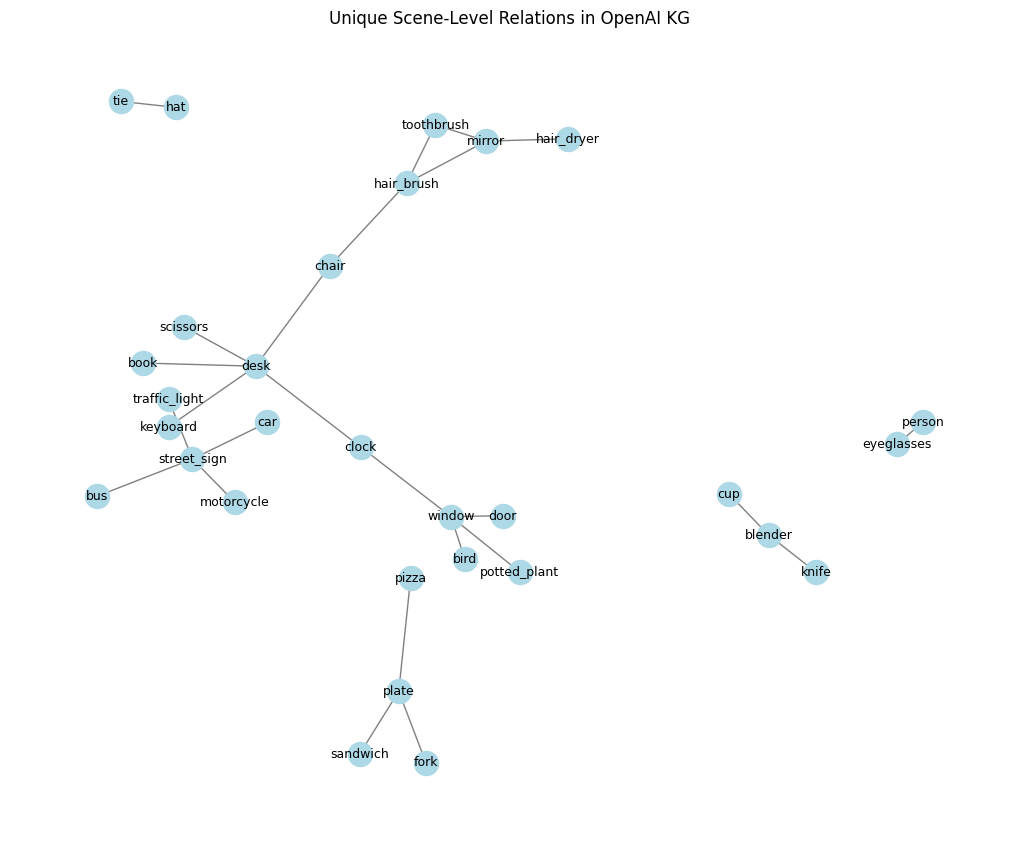

In [ ]:
import networkx as nx
G = nx.Graph()
for src, dst, w in top_relations:
    G.add_edge(src, dst, weight=w)

plt.figure(figsize=(10,8))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', font_size=9)
plt.title("Unique Scene-Level Relations in OpenAI KG")
plt.show()


In [ ]:
import pandas as pd

data = [
    ["window→door", "Indoor architecture", "None", "Captures spatial co-occurrence"],
    ["bird→window", "Outdoor/indoor boundary", "None", "Scene realism"],
    ["person→eyeglasses", "Wearable object", "person→see", "Visual concreteness"],
    ["window→clock", "Indoor wall items", "None", "Spatial context"],
    ["knife→blender", "Kitchen tools", "knife→cut", "Functional co-use"],
    ["cup→blender", "Kitchen tools", "None", "Object co-use"],
    ["desk→clock", "Office/home setup", "None", "Scene realism"],
    ["desk→scissors", "Stationery on desk", "None", "Fine-grained context"],
]

df = pd.DataFrame(data, columns=["OpenAI Relation", "Meaning/Context", "ConceptNet Equivalent", "Advantage"])
df.to_markdown(index=False)


'| OpenAI Relation   | Meaning/Context         | ConceptNet Equivalent   | Advantage                      |\n|:------------------|:------------------------|:------------------------|:-------------------------------|\n| window→door       | Indoor architecture     | None                    | Captures spatial co-occurrence |\n| bird→window       | Outdoor/indoor boundary | None                    | Scene realism                  |\n| person→eyeglasses | Wearable object         | person→see              | Visual concreteness            |\n| window→clock      | Indoor wall items       | None                    | Spatial context                |\n| knife→blender     | Kitchen tools           | knife→cut               | Functional co-use              |\n| cup→blender       | Kitchen tools           | None                    | Object co-use                  |\n| desk→clock        | Office/home setup       | None                    | Scene realism                  |\n| desk→scissors     | Stati